<a href="https://colab.research.google.com/github/kh1z3r/chicago-food-inspections/blob/main/food_inspections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Food Inspections

 Group 11D: Althan Nguyen, Eva Wonsowicz,Fareeha Gullany, Joshua Jacob, Khizer Butt, Rodas, Snehal Agrawal

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
CSV_PATH = '/content/drive/MyDrive/AI4ALL/Food_Inspections_20260628.csv'
df = pd.read_csv(CSV_PATH, dtype={'Zip': 'string', 'License #': 'string'})
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(312415, 17)


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location
0,2639042,SHELL,SHELL,3090559,Grocery Store,Risk 3 (Low),9802 S HALSTED ST,CHICAGO,IL,60628,06/25/2026,License,Pass,NaN,41.715805,-87.643208,"(41.71580477012766, -87.64320825324427)"
1,2639047,JUNIOR CHEFS KITCHEN,JUNIOR CHEFS KITCHEN,3065477,Restaurant,Risk 1 (High),1061 W VAN BUREN ST,CHICAGO,IL,60607,06/25/2026,License,Pass,51. PLUMBING INSTALLED; PROPER BACKFLOW DEVICE...,41.876456,-87.654296,"(41.87645614541188, -87.65429579519606)"
2,2639049,JUNIOR CHEFS KITCHEN,JUNIOR CHEFS KITCHEN,3065478,Restaurant,Risk 1 (High),1061 W VAN BUREN ST,CHICAGO,IL,60607,06/25/2026,License,Pass,NaN,41.876456,-87.654296,"(41.87645614541188, -87.65429579519606)"
3,2638998,BREAKFAST HOUSE,BREAKFAST HOUSE,3087028,Restaurant,Risk 3 (Low),501 W DIVERSEY PKWY,CHICAGO,IL,60614,06/25/2026,License,Pass,NaN,41.932757,-87.641488,"(41.9327574222532, -87.6414877332763)"
4,2639009,TARRA,TARRA,3086370,Restaurant,Risk 3 (Low),121 W HUBBARD ST,CHICAGO,IL,60654,06/25/2026,License,Pass,NaN,41.889900,-87.632032,"(41.889900231874854, -87.63203247618843)"


In [14]:
#Target: We predict the Results column as Fail = 1 vs not-Fail = 0 (Pass and Pass w/ Conditions = 0; we drop non-decision outcomes like Out of Business and No Entry).

In [15]:
import numpy as np

# "Results" is text (Pass, Fail, ...). Convert it to a 0/1 target the model can learn.
# Normalize the text first so spacing/case differences don't create duplicate categories.
r = df["Results"].str.strip().str.upper()

# Fail = 1; Pass and Pass w/ Conditions = 0. Any other result (Out of Business, No Entry, Not Ready)
# isn't a real pass/fail decision, so map it to NaN here and drop it on the next line.
fail_map = {"FAIL": 1, "PASS": 0, "PASS W/ CONDITIONS": 0}
df["y"] = r.map(fail_map)

before = len(df)
df = df[df["y"].notna()].copy()      # keep only genuine pass/fail rows
df["y"] = df["y"].astype(int)

print(f"Rows: {before} -> {len(df)}")
print(f"Fail rate: {df['y'].mean():.1%}")

Rows: 312415 -> 268226
Fail rate: 22.4%


In [16]:
# Use only information available BEFORE an inspection. We deliberately exclude the Violations column,
# because it's recorded during the inspection - feeding it in would leak the answer to the model.

# Facility Type has 527 messy values. Keep the 15 most common, lump the rest into "OTHER",
# and fill blanks with the most common value.
ft = df["Facility Type"].astype("string").str.strip().str.upper()
ft = ft.fillna(ft.mode(dropna=True)[0])
top15 = ft.value_counts().head(15).index
df["FacilityType_g"] = ft.where(ft.isin(top15), "OTHER")

# Inspection Type has 111 values. Collapse them into a few families. This feature matters because
# Complaint and Re-Inspection visits target already-flagged places, so it lets the model tell
# "inspected more often" apart from "actually worse".
it = df["Inspection Type"].astype("string").str.strip().str.upper().fillna("OTHER")
def fam(s):
    if "RE-INSPECTION" in s or "REINSPECTION" in s: return "Re-Inspection"
    if "COMPLAINT" in s: return "Complaint"
    if "CANVASS" in s:   return "Canvass"
    if "LICENSE" in s:   return "License"
    return "Other"
df["InspType_g"] = it.map(fam)

# Risk has three real levels plus a few blank / "All" rows. Drop those rows.
rk = df["Risk"].astype("string").str.strip()
valid_risk = ["Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)"]
df = df[rk.isin(valid_risk)].copy()
df["Risk_g"] = df["Risk"].str.strip()

# Zip is the location feature. Drop blank zips and keep it as text - a ZIP is a category,
# not a quantity (60614 isn't "greater than" 60612).
df = df[df["Zip"].notna() & (df["Zip"].str.strip() != "")].copy()
df["Zip"] = df["Zip"].str.strip()

# License # identifies the establishment; we'll use it to group the split. Drop blank/0 licenses,
# since a missing group would silently merge many unrelated establishments into one.
lic = df["License #"].fillna("0").str.strip()
df = df[(lic != "") & (lic != "0")].copy()
df["lic"] = df["License #"].str.strip()

print("Rows after cleaning:", len(df), "| distinct licenses:", df["lic"].nunique())
print(df["InspType_g"].value_counts())

Rows after cleaning: 267477 | distinct licenses: 43356
InspType_g
Canvass          130539
Re-Inspection     59205
License           37265
Complaint         36946
Other              3522
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import GroupShuffleSplit

# The same restaurant appears many times. If some of its inspections go to training and others to
# testing, the model can memorize that specific place and post an inflated score. GroupShuffleSplit
# keeps every inspection of one license entirely in train OR test - never both.
FEATURES = ["FacilityType_g", "Risk_g", "InspType_g", "Zip"]
X = df[FEATURES]
y = df["y"].values
groups = df["lic"].values                 # group = the establishment's license number

# random_state=42 fixes the split so every teammate gets identical train/test rows.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y[train_idx], y[test_idx]

# Sanity check: no license should appear in both sets.
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f"Train {len(Xtr)} | Test {len(Xte)} | overlapping licenses: {len(overlap)} (must be 0)")

Train 213769 | Test 53708 | overlapping licenses: 0 (must be 0)


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# The features are text categories, so we one-hot encode them (one 0/1 column per category).
# Keeping the encoder inside a Pipeline means it's fit on the training data only, then applied to test.
def make_pipe(model, feats):
    enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), feats)])
    return Pipeline([("enc", enc), ("model", model)])

# We score on RECALL of failures (the share of real fails we catch), not overall accuracy: since ~78%
# of inspections pass, a model that always says "Pass" is 78% accurate yet catches nothing useful.
def report(name, ypred):
    print(f"\n[{name}]  recall={recall_score(yte, ypred, zero_division=0):.3f} "
          f"precision={precision_score(yte, ypred, zero_division=0):.3f} "
          f"F1={f1_score(yte, ypred, zero_division=0):.3f}")
    print("confusion [[TN FP][FN TP]]:\n", confusion_matrix(yte, ypred))

# Baseline: always predict Pass. Catches zero failures by design - the bar our models must clear.
report("Naive baseline (always Pass)", np.zeros_like(yte))

# Logistic regression: simple and explainable. class_weight="balanced" weights the rare failures
# more heavily so the model doesn't just ignore them.
logreg = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), FEATURES)
logreg.fit(Xtr, ytr)
report("Logistic Regression", logreg.predict(Xte))

# Random forest: many decision trees combined - usually more accurate and can rank feature importance.
# n_estimators=150 runs in ~1-2 min on Colab; raise to 300 for the final version.
rf = make_pipe(RandomForestClassifier(class_weight="balanced", n_estimators=150,
                                      random_state=42, n_jobs=-1), FEATURES)
rf.fit(Xtr, ytr)
report("Random Forest", rf.predict(Xte))


[Naive baseline (always Pass)]  recall=0.000 precision=0.000 F1=0.000
confusion [[TN FP][FN TP]]:
 [[41621     0]
 [12087     0]]

[Logistic Regression]  recall=0.698 precision=0.296 F1=0.415
confusion [[TN FP][FN TP]]:
 [[21520 20101]
 [ 3649  8438]]

[Random Forest]  recall=0.669 precision=0.304 F1=0.418
confusion [[TN FP][FN TP]]:
 [[23084 18537]
 [ 3999  8088]]


log loss (lower = better-calibrated probabilities):
  baseline (constant base rate): 0.533
  logistic regression         : 0.658
  random forest               : 0.701
  ^ both models score WORSE than the constant baseline -> they're over-confident.

Random forest calibration (what it said vs what actually happened):
  said   2%  ->  actually  13%
  said  16%  ->  actually   9%
  said  25%  ->  actually  10%
  said  35%  ->  actually  16%
  said  45%  ->  actually  20%
  said  55%  ->  actually  27%
  said  65%  ->  actually  34%
  said  74%  ->  actually  39%
  said  83%  ->  actually  43%
  said  95%  ->  actually  49%


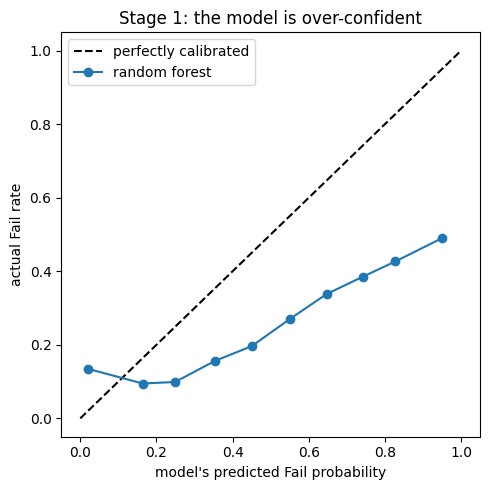

In [22]:
from sklearn.metrics import log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# ── Stage 1: is the model's CONFIDENCE trustworthy? (log loss + calibration) ──
# Recall/precision only grade the yes/no call. Log loss grades the *probabilities*: it punishes
# being confident and wrong. We compare three sets of Fail-probabilities on the test set.
proba_rf   = rf.predict_proba(Xte)[:, 1]
proba_lr   = logreg.predict_proba(Xte)[:, 1]
base_rate  = ytr.mean()                       # naive "everyone fails at the overall base rate"
proba_base = np.full(len(yte), base_rate)

print("log loss (lower = better-calibrated probabilities):")
print(f"  baseline (constant base rate): {log_loss(yte, proba_base):.3f}")
print(f"  logistic regression         : {log_loss(yte, proba_lr):.3f}")
print(f"  random forest               : {log_loss(yte, proba_rf):.3f}")
print("  ^ both models score WORSE than the constant baseline -> they're over-confident.")

# Calibration curve: split predictions into 10 fixed-width confidence bins, then for each bin compare
# the model's average predicted Fail-probability against how often those places ACTUALLY failed.
frac_pos, mean_pred = calibration_curve(yte, proba_rf, n_bins=10)
print("\nRandom forest calibration (what it said vs what actually happened):")
for p, a in zip(mean_pred, frac_pos):
    print(f"  said {p:4.0%}  ->  actually {a:4.0%}")

plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
plt.plot(mean_pred, frac_pos, "o-", label="random forest")
plt.xlabel("model's predicted Fail probability"); plt.ylabel("actual Fail rate")
plt.title("Stage 1: the model is over-confident"); plt.legend(); plt.tight_layout(); plt.show()

Drop in Fail-recall when shuffled (higher = more important):
InspType_g        0.1269
Zip               0.0778
FacilityType_g    0.0689
Risk_g            0.0361


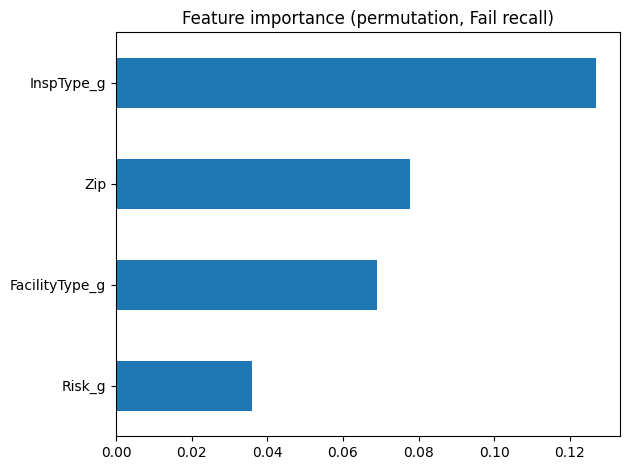

In [23]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Permutation importance shows how much the model leans on each feature: shuffle one feature's values
# in the test set and measure how far Fail-recall drops. A bigger drop means that feature mattered more.
# We shuffle the original column (before encoding), so each feature - including all the ZIP columns
# together - is measured as one group. We sample 15k test rows to keep it fast.
samp = min(15000, len(Xte))
si = np.random.RandomState(42).choice(len(Xte), samp, replace=False)
pi = permutation_importance(rf, Xte.iloc[si], yte[si], scoring="recall",
                            n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Drop in Fail-recall when shuffled (higher = more important):")
print(imp.round(4).to_string())

imp.sort_values().plot.barh()
plt.title("Feature importance (permutation, Fail recall)")
plt.tight_layout(); plt.show()

In [24]:
from sklearn.metrics import average_precision_score

# ── Does the model actually use the neighborhood? (with-ZIP vs without-ZIP) ──
# We train the same Random Forest twice on the identical train/test split: once with Zip
# as a feature, once with it removed. If dropping Zip barely changes performance, the model
# is mostly leaning on the restaurant's own attributes (facility type, risk, inspection type) -
# a good sign for fairness. If performance drops a lot, the model is leaning on neighborhood.
#
# We compare using PR-AUC (average precision), not recall alone. Recall by itself is
# misleading here: dropping a feature can shift the recall/precision trade-off in either
# direction at a fixed 0.5 threshold, without changing how good the model actually is.
# PR-AUC summarizes performance across all thresholds, so it isolates whether Zip is
# genuinely informative rather than just moving where the threshold happens to cut.

FEATURES_NO_ZIP = [f for f in FEATURES if f != "Zip"]

rf_with_zip = make_pipe(
    RandomForestClassifier(class_weight="balanced", n_estimators=150, random_state=42, n_jobs=-1),
    FEATURES
)
rf_with_zip.fit(Xtr[FEATURES], ytr)

rf_no_zip = make_pipe(
    RandomForestClassifier(class_weight="balanced", n_estimators=150, random_state=42, n_jobs=-1),
    FEATURES_NO_ZIP
)
rf_no_zip.fit(Xtr[FEATURES_NO_ZIP], ytr)

# Probability of "Fail" (class 1) for each restaurant, from each model
proba_with_zip = rf_with_zip.predict_proba(Xte[FEATURES])[:, 1]
proba_no_zip   = rf_no_zip.predict_proba(Xte[FEATURES_NO_ZIP])[:, 1]

pr_auc_with_zip = average_precision_score(yte, proba_with_zip)
pr_auc_no_zip   = average_precision_score(yte, proba_no_zip)

print(f"PR-AUC WITH Zip:    {pr_auc_with_zip:.4f}")
print(f"PR-AUC WITHOUT Zip: {pr_auc_no_zip:.4f}")
print(f"Change: {pr_auc_no_zip - pr_auc_with_zip:+.4f}")

# How many individual predictions flip (Fail <-> not-Fail at the standard 0.5 cutoff)
# when Zip is removed - a second, more concrete way to see how much Zip is driving decisions.
pred_with_zip = (proba_with_zip >= 0.5).astype(int)
pred_no_zip   = (proba_no_zip >= 0.5).astype(int)
n_flipped = (pred_with_zip != pred_no_zip).sum()

print(f"\nPredictions that flip when Zip is dropped: {n_flipped} / {len(yte)} "
      f"({n_flipped/len(yte):.1%})")

PR-AUC WITH Zip:    0.3270
PR-AUC WITHOUT Zip: 0.3097
Change: -0.0173

Predictions that flip when Zip is dropped: 13207 / 53708 (24.6%)


In [25]:
import pandas as pd

# ── ZIP-level flip breakdown ──
# For each restaurant in the test set, we know: its actual ZIP, whether it truly failed,
# and how it was predicted with vs. without Zip in the model. Grouping by ZIP lets us see
# whether the 24.6% of flipped predictions are spread evenly across the city, or concentrated
# in specific neighborhoods - and whether Zip is systematically pushing predictions up
# (more flagged as Fail) or down (fewer flagged) in particular areas.

flip_df = pd.DataFrame({
    "Zip": Xte["Zip"].values,
    "y_true": yte,
    "pred_with_zip": pred_with_zip,
    "pred_no_zip": pred_no_zip,
})

# A "flip" is any restaurant whose prediction changes when Zip is removed.
flip_df["flipped"] = flip_df["pred_with_zip"] != flip_df["pred_no_zip"]

# Direction of the flip matters: does adding Zip push MORE restaurants toward "predicted Fail"
# in this area (no_zip=0 -> with_zip=1), or FEWER (no_zip=1 -> with_zip=0)?
flip_df["flip_up"]   = (flip_df["pred_no_zip"] == 0) & (flip_df["pred_with_zip"] == 1)  # Zip made it worse
flip_df["flip_down"] = (flip_df["pred_no_zip"] == 1) & (flip_df["pred_with_zip"] == 0)  # Zip made it better

# Aggregate per ZIP. Only keep ZIPs with a reasonable sample size in the test set so we're not
# reading noise into a ZIP that only had 3 restaurants.
zip_summary = flip_df.groupby("Zip").agg(
    n_test=("y_true", "size"),
    true_fail_rate=("y_true", "mean"),
    flip_rate=("flipped", "mean"),
    flip_up_rate=("flip_up", "mean"),    # Zip is pushing predictions toward MORE scrutiny here
    flip_down_rate=("flip_down", "mean"),  # Zip is pushing predictions toward LESS scrutiny here
).reset_index()

zip_summary = zip_summary[zip_summary["n_test"] >= 30].copy()  # drop tiny/noisy ZIPs
zip_summary = zip_summary.sort_values("flip_rate", ascending=False)

print("ZIP codes with the highest flip rates (Zip most changes predictions here):")
print(zip_summary.head(15).round(3).to_string(index=False))

print("\nCitywide averages, for comparison:")
print(f"Mean flip rate across ZIPs: {zip_summary['flip_rate'].mean():.3f}")
print(f"Mean flip_up rate:          {zip_summary['flip_up_rate'].mean():.3f}")
print(f"Mean flip_down rate:        {zip_summary['flip_down_rate'].mean():.3f}")

# Does the flip rate correlate with the true fail rate? If Zip mostly flips predictions in
# ZIPs that already have high true failure rates, that's more defensible (Zip may be a
# reasonable proxy for real risk). If it flips predictions in LOW true-fail-rate ZIPs, that's
# the concerning case - Zip could be inflating scrutiny somewhere without real cause.
corr = zip_summary["flip_rate"].corr(zip_summary["true_fail_rate"])
print(f"\nCorrelation between flip_rate and true_fail_rate across ZIPs: {corr:.3f}")

ZIP codes with the highest flip rates (Zip most changes predictions here):
  Zip  n_test  true_fail_rate  flip_rate  flip_up_rate  flip_down_rate
60634    1215           0.193      0.635         0.008           0.626
60646     326           0.175      0.626         0.021           0.604
60666     754           0.125      0.615         0.000           0.615
60604     389           0.154      0.609         0.000           0.609
60601     822           0.142      0.608         0.000           0.608
60602     380           0.195      0.600         0.008           0.592
60638     617           0.144      0.587         0.000           0.587
60606     736           0.145      0.584         0.003           0.582
60611    1724           0.179      0.573         0.000           0.573
60610    1170           0.186      0.558         0.022           0.536
60661     773           0.176      0.545         0.004           0.541
60652     452           0.162      0.542         0.000           0.542
60

In [26]:
from sklearn.metrics import recall_score, precision_score, f1_score

# ── Stage 3: can we fix the over-flagging by raising the decision threshold? ──
# The model calls Fail whenever its probability >= 0.5. Because class_weight="balanced" pushes it
# to over-predict Fail, raising that cutoff trades some recall for far fewer false alarms. We sweep
# the threshold, THEN check whether tuning shrinks the per-ZIP gap or just lowers everything.
proba_rf = rf.predict_proba(Xte)[:, 1]
def fpr(yt, yp): neg = (yt == 0); return (yp[neg] == 1).mean()

print("threshold sweep:")
print(f"{'thr':>5} {'recall':>7} {'prec':>6} {'FPR':>6} {'F1':>6}")
for thr in np.arange(0.30, 0.81, 0.05):
    p = (proba_rf >= thr).astype(int)
    print(f"{thr:5.2f} {recall_score(yte,p,zero_division=0):7.3f} {precision_score(yte,p,zero_division=0):6.3f} "
          f"{fpr(yte,p):6.3f} {f1_score(yte,p,zero_division=0):6.3f}")

# does raising the threshold shrink the neighborhood disparity, or just move everything down?
td = pd.DataFrame({"Zip": Xte["Zip"].values, "y": yte, "proba": proba_rf})
keep = td["Zip"].value_counts(); keep = keep[keep >= 100].index
def per_zip_fpr(thr, min_pass=30):
    d = td.copy(); d["pred"] = (d["proba"] >= thr).astype(int)
    g = d[d["y"] == 0].groupby("Zip", observed=True)["pred"].agg(FPR="mean", n="size")
    return g[(g["n"] >= min_pass) & (g.index.isin(keep))]

for label, thr in [("default 0.50", 0.50), ("tuned 0.55", 0.55), ("tuned 0.60", 0.60)]:
    g = per_zip_fpr(thr); p = (proba_rf >= thr).astype(int)
    ratio = g["FPR"].quantile(0.9) / max(g["FPR"].quantile(0.1), 1e-6)
    print(f"\n== {label} ==  overall FPR {fpr(yte,p):.3f} | recall {recall_score(yte,p,zero_division=0):.3f}")
    print(f"   per-ZIP FPR: min {g['FPR'].min():.3f}  median {g['FPR'].median():.3f}  max {g['FPR'].max():.3f}")
    print(f"   top-vs-bottom-decile ratio: {ratio:.1f}x  (higher = wider neighborhood gap)")

threshold sweep:
  thr  recall   prec    FPR     F1
 0.30   0.904  0.258  0.754  0.402
 0.35   0.876  0.266  0.703  0.408
 0.40   0.827  0.275  0.632  0.413
 0.45   0.775  0.286  0.560  0.418
 0.50   0.669  0.304  0.445  0.418
 0.55   0.529  0.319  0.327  0.398
 0.60   0.306  0.354  0.162  0.328
 0.65   0.202  0.374  0.098  0.262
 0.70   0.095  0.396  0.042  0.153
 0.75   0.050  0.416  0.020  0.089
 0.80   0.020  0.438  0.008  0.039

== default 0.50 ==  overall FPR 0.445 | recall 0.669
   per-ZIP FPR: min 0.018  median 0.506  max 0.671
   top-vs-bottom-decile ratio: 5.4x  (higher = wider neighborhood gap)

== tuned 0.55 ==  overall FPR 0.327 | recall 0.529
   per-ZIP FPR: min 0.006  median 0.285  max 0.624
   top-vs-bottom-decile ratio: 7.8x  (higher = wider neighborhood gap)

== tuned 0.60 ==  overall FPR 0.162 | recall 0.306
   per-ZIP FPR: min 0.000  median 0.136  max 0.470
   top-vs-bottom-decile ratio: 21.8x  (higher = wider neighborhood gap)


ZIPs kept (>=100 test rows): 57

Top 15 ZIPs by false-positive rate (most over-flagged as Fail):
  Zip   fpr   fnr  n_test
60620 0.671 0.154    1090
60623 0.664 0.159    1317
60649 0.660 0.205     745
60619 0.642 0.169    1174
60647 0.637 0.203    1903
60615 0.636 0.195     529
60617 0.635 0.208    1073
60636 0.635 0.205     631
60707 0.632 0.148     288
60628 0.632 0.085    1040
60640 0.624 0.150    1377
60621 0.622 0.279     476
60651 0.620 0.188     670
60608 0.619 0.224    1491
60639 0.614 0.161    1482

Bottom 5 ZIPs (lowest FPR), for contrast:
  Zip   fpr   fnr  n_test
60666 0.018 0.926     754
60604 0.055 0.850     389
60634 0.064 0.816    1215
60646 0.100 0.772     326
60601 0.113 0.726     822

Citywide FPR: 0.445 | Citywide FNR: 0.331
FPR spread: min 0.018  median 0.506  max 0.671
Worst ZIP FPR is 1.5x the citywide rate


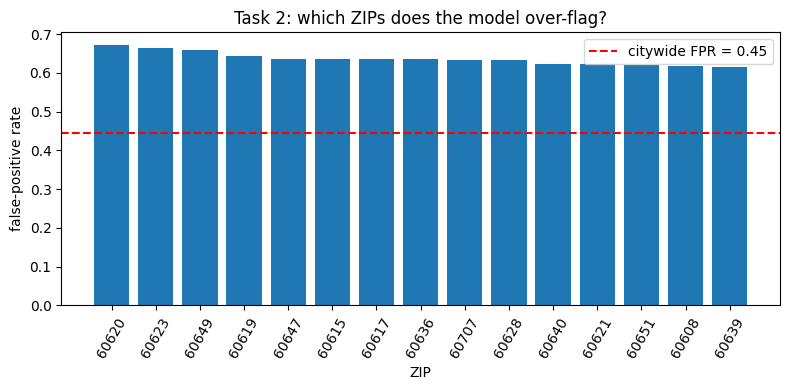

In [30]:
!pip install -q fairlearn
from fairlearn.metrics import MetricFrame, false_positive_rate, false_negative_rate
import matplotlib.pyplot as plt

# ── Task 2: per-ZIP error rates (fairness check)  —  analysis by Jacob ──
# Break the model's mistakes down by neighborhood. A false POSITIVE = a place that passed but got
# flagged as Fail (unearned scrutiny); a false NEGATIVE = a real Fail the model cleared (a missed risk).
# We use the with-Zip model's predictions (pred_with_zip), since that's the actual model in question.
# This is a different question from the flip analysis, so we don't reuse pred_no_zip here.

mf = MetricFrame(
    metrics={"fpr": false_positive_rate, "fnr": false_negative_rate},
    y_true=yte,
    y_pred=pred_with_zip,
    sensitive_features=Xte["Zip"]
)

zip_fairness = mf.by_group.reset_index()
zip_fairness.columns = ["Zip", "fpr", "fnr"]

# attach test-set counts so we can filter out tiny/noisy ZIPs (keep ZIPs with 100+ test rows)
counts = pd.Series(Xte["Zip"].values).value_counts().rename("n_test")
zip_fairness = zip_fairness.merge(counts, left_on="Zip", right_index=True)
zip_fairness = zip_fairness[zip_fairness["n_test"] >= 100].copy()
zip_fairness = zip_fairness.sort_values("fpr", ascending=False)

print(f"ZIPs kept (>=100 test rows): {len(zip_fairness)}\n")
print("Top 15 ZIPs by false-positive rate (most over-flagged as Fail):")
print(zip_fairness.head(15).round(3).to_string(index=False))
print("\nBottom 5 ZIPs (lowest FPR), for contrast:")
print(zip_fairness.sort_values("fpr").head(5).round(3).to_string(index=False))

# citywide error rates + how extreme the worst ZIP is relative to the city
overall_fpr = false_positive_rate(yte, pred_with_zip)
overall_fnr = false_negative_rate(yte, pred_with_zip)
print(f"\nCitywide FPR: {overall_fpr:.3f} | Citywide FNR: {overall_fnr:.3f}")
print(f"FPR spread: min {zip_fairness['fpr'].min():.3f}  "
      f"median {zip_fairness['fpr'].median():.3f}  max {zip_fairness['fpr'].max():.3f}")
print(f"Worst ZIP FPR is {zip_fairness['fpr'].max()/overall_fpr:.1f}x the citywide rate")

# chart: the 15 most over-flagged ZIPs against the citywide FPR line
top = zip_fairness.head(15)
plt.figure(figsize=(8, 4))
plt.bar(top["Zip"].astype(str), top["fpr"])
plt.axhline(overall_fpr, color="red", ls="--", label=f"citywide FPR = {overall_fpr:.2f}")
plt.ylabel("false-positive rate"); plt.xlabel("ZIP")
plt.title("Task 2: which ZIPs does the model over-flag?"); plt.xticks(rotation=60)
plt.legend(); plt.tight_layout(); plt.show()

In [29]:
# ── Task 4: is the over-flagging real, or an artifact of WHO gets inspected? ──
# Complaint and Re-Inspection visits target already-flagged places, so a ZIP that gets more of
# those can look "worse" for reasons unrelated to hygiene. Two checks: (1) recompute the
# false-positive rate on ROUTINE (Canvass) inspections only, and (2) see whether a ZIP's FPR
# tracks how enforcement-heavy its inspection mix is.
pred_rf = rf.predict(Xte)
t = pd.DataFrame({"Zip": Xte["Zip"].values, "insp": Xte["InspType_g"].values,
                  "y": yte, "pred": pred_rf})
keep = t["Zip"].value_counts(); keep = keep[keep >= 100].index    # ZIPs with >=100 test rows

def per_zip_fpr(frame, min_pass=30):
    passed = frame[frame["y"] == 0]
    g = passed.groupby("Zip", observed=True)["pred"].agg(FPR="mean", n_pass="size")
    return g[g["n_pass"] >= min_pass]

fpr_all  = per_zip_fpr(t); fpr_all = fpr_all[fpr_all.index.isin(keep)]
canv     = t[t["insp"] == "Canvass"]
fpr_canv = per_zip_fpr(canv)

print(f"overall FPR, all inspection types  : {t[t.y==0].pred.mean():.3f}")
print(f"overall FPR, Canvass (routine) only: {canv[canv.y==0].pred.mean():.3f}")
print(f"\nper-ZIP FPR spread, all types (n={len(fpr_all)}):   {fpr_all.FPR.min():.3f} to {fpr_all.FPR.max():.3f}")
print(f"per-ZIP FPR spread, Canvass  (n={len(fpr_canv)}):   {fpr_canv.FPR.min():.3f} to {fpr_canv.FPR.max():.3f}")

# does a ZIP's false-positive rate track its share of enforcement (Complaint/Re-Inspection) visits?
enf = t[t["Zip"].isin(keep)].groupby("Zip", observed=True)["insp"].apply(
    lambda s: s.isin(["Complaint", "Re-Inspection"]).mean()).rename("enf_share")
m = fpr_all.join(enf)
print(f"\ncorr(per-ZIP FPR, enforcement share): {m.FPR.corr(m.enf_share):.3f}")

cmp = (fpr_all[["FPR"]].rename(columns={"FPR": "FPR_all"})
       .join(fpr_canv[["FPR"]].rename(columns={"FPR": "FPR_canvass"}))
       .join(enf))
print("\nTop 10 over-flagged ZIPs: all-types vs Canvass-only FPR + enforcement share:")
print(cmp.sort_values("FPR_all", ascending=False).head(10).round(3).to_string())

overall FPR, all inspection types  : 0.445
overall FPR, Canvass (routine) only: 0.502

per-ZIP FPR spread, all types (n=57):   0.018 to 0.671
per-ZIP FPR spread, Canvass  (n=58):   0.000 to 1.000

corr(per-ZIP FPR, enforcement share): 0.693

Top 10 over-flagged ZIPs: all-types vs Canvass-only FPR + enforcement share:
       FPR_all  FPR_canvass  enf_share
Zip                                   
60620    0.671        0.988      0.517
60623    0.664        0.948      0.348
60649    0.660        0.806      0.525
60619    0.642        0.902      0.551
60647    0.637        0.834      0.354
60615    0.636        0.914      0.442
60617    0.635        0.797      0.439
60636    0.635        0.971      0.534
60707    0.632        0.790      0.302
60628    0.632        0.907      0.463
